### Macroeconomic Theory 2 - New York University 
### Prof. Corina Boar - Spring 2025 

##### Aiyagari Model - Discrete Time
By: Rafael Lincoln 
###### Date: 25 apr 2025


Description: Code for the solution of the Aiyagari model using the EGM method
              together with a newton method for the stationary equilibrium.
              
              



#### Set my local working directory

Set to your local working directory with all codes for it to work


In [95]:
import sys
sys.path.append("/Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/PSets Corina/My Solutions/PS4")

In [96]:
# Import Libraries
import numpy as np
import ha_utils as ha_utils
import matplotlib.pyplot as plt
import aiyagari as ay
from tqdm.notebook import tqdm


In [97]:
import importlib
importlib.reload(ay)

<module 'aiyagari' from '/Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/PSets Corina/My Solutions/PS4/aiyagari.py'>

In [98]:
# 1. Calibration/Parametrization ------------------------------------------

# Income Process
mu = 0.0  # mean of (log) income shocks
rho = 0.9  # persistence of (log) income shocks
sigma_e = 0.1  # standard deviation of (log)income shocks
nz = 7  # number of income states
Pi, z_grid = ha_utils.rouwenhorst_AR1(mu,rho, sigma_e, nz)


# Asset Grid
bl = 0.0  # lower bound of asset grid
ba = 50.0  # upper bound of asset grid
na = 300  # number of asset grid points
a_grid = ha_utils.power_grid(bl, ba, na)


# Model Parameters
beta = 0.96  # discount factor
gamma = 2.0  # coefficient of relative risk aversion
delta = 0.08  # depreciation rate
alpha = 0.36  # capital share in income


#### Calculate the Aggregate Supply & Demand of capital

In [99]:
# Build the r_grid
nr = 30

rgrid= np.linspace(0.01, 1/beta -1+ delta, nr)

K_s = np.zeros(nr)
K_d = np.zeros(nr)

# Calculate the Aggregate Demand of Capital


print("Calculating Aggregate Supply and Demand of Capital...")
for ir in tqdm(range(nr), desc="Aggregate Supply loop"):
    r = rgrid[ir]
    ff = ay.Firms(alpha, delta, r)
    w = ff.eq_wage()
    hh = ay.Households(a_grid, z_grid, Pi, beta, r, w, gamma)
    hh.steady_state()
    L = hh.aggregates['L']
    # Calculate aggregates
    aggregates = hh.aggregates
    K_s[ir] = aggregates['A']
    K_d[ir] = ff.capital_demand(L)


Calculating Aggregate Supply and Demand of Capital...


Aggregate Supply loop:   0%|          | 0/30 [00:00<?, ?it/s]

EGM converged in 114 iters, Δ=8.87e-07
EGM converged in 126 iters, Δ=9.72e-07
EGM converged in 142 iters, Δ=9.00e-07
EGM converged in 161 iters, Δ=9.17e-07
EGM converged in 185 iters, Δ=9.37e-07
EGM converged in 210 iters, Δ=9.87e-07
EGM converged in 240 iters, Δ=9.74e-07
EGM converged in 262 iters, Δ=9.74e-07
EGM converged in 262 iters, Δ=9.96e-07
EGM converged in 250 iters, Δ=9.67e-07
EGM converged in 235 iters, Δ=9.87e-07
EGM converged in 222 iters, Δ=9.48e-07
EGM converged in 209 iters, Δ=9.65e-07
EGM converged in 197 iters, Δ=9.77e-07
EGM converged in 186 iters, Δ=9.71e-07
EGM converged in 176 iters, Δ=9.46e-07
EGM converged in 167 iters, Δ=9.03e-07
EGM converged in 158 iters, Δ=9.50e-07
EGM converged in 150 iters, Δ=9.95e-07
EGM converged in 144 iters, Δ=8.80e-07
EGM converged in 138 iters, Δ=8.58e-07
EGM converged in 132 iters, Δ=9.44e-07
EGM converged in 127 iters, Δ=8.32e-07
EGM converged in 121 iters, Δ=9.89e-07
EGM converged in 117 iters, Δ=8.38e-07
EGM converged in 112 iter

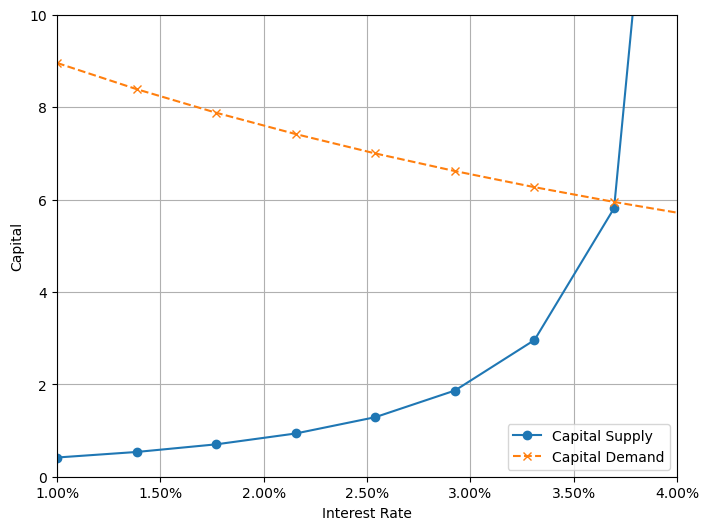

In [94]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(rgrid, K_s, marker='o', linestyle='-', label="Capital Supply")
ax.plot(rgrid, K_d, marker='x', linestyle='--', label="Capital Demand")
ax.set_xlabel("Interest Rate")
ax.set_ylabel("Capital")
ax.set_ylim(0,10)
ax.set_xlim(0.01, 0.04)
# ax.set_title("Aggregate Capital Supply & Demand vs Interest Rate")
# Format x-axis ticks as percentages assuming rgrid number represent fractions
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.grid(True)
plt.show()

### Finding the Equilibrium Interest Rate 

In [75]:
diff, hh, out = ay.solve_steady_state(a_grid, z_grid, Pi, alpha, delta, beta, gamma)

EGM converged in 264 iters, Δ=9.77e-07
EGM converged in 264 iters, Δ=9.77e-07
EGM converged in 264 iters, Δ=9.77e-07
EGM converged in 264 iters, Δ=9.77e-07
EGM converged in 265 iters, Δ=9.70e-07
EGM converged in 264 iters, Δ=9.88e-07
EGM converged in 263 iters, Δ=9.79e-07
EGM converged in 262 iters, Δ=9.95e-07
EGM converged in 262 iters, Δ=9.88e-07
EGM converged in 262 iters, Δ=9.88e-07
EGM converged in 262 iters, Δ=9.88e-07
EGM converged in 262 iters, Δ=9.88e-07
EGM converged in 262 iters, Δ=9.88e-07


compute the distribution and policy functions

In [76]:
hh.steady_state()

# stationary distribution
stationary_dist = hh.g
# Policy_functions
pol_functions = hh.pol_functions


EGM converged in 262 iters, Δ=9.88e-07


#### Plot Marginal Distribution of Wealth

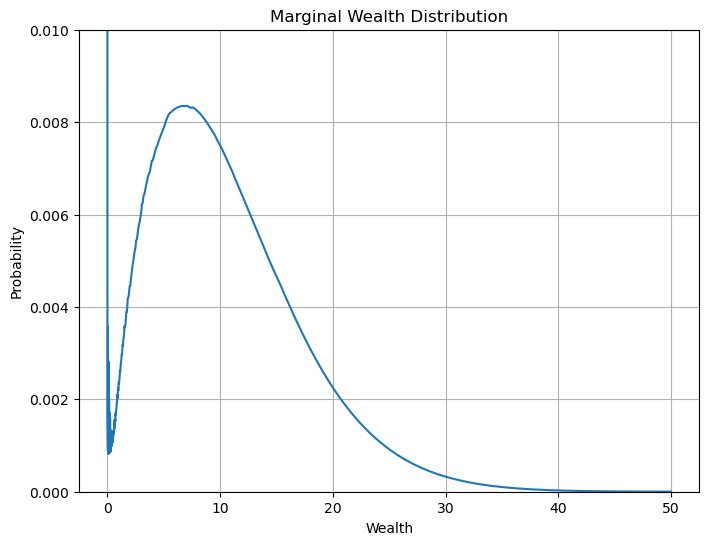

In [78]:
marginal_wealth = stationary_dist.sum(axis=0)

# Plot the marginal distribution of wealth for the lowest and highest income levels
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(a_grid, marginal_wealth)
# ax.plot(a_grid, marginal_high, label="Highest Income Level")
ax.set_xlabel("Wealth")
ax.set_ylabel("Density")
ax.set_ylim(0, 0.01)
ax.set_title("Marginal Wealth Distribution")
ax.grid(True)
plt.show()

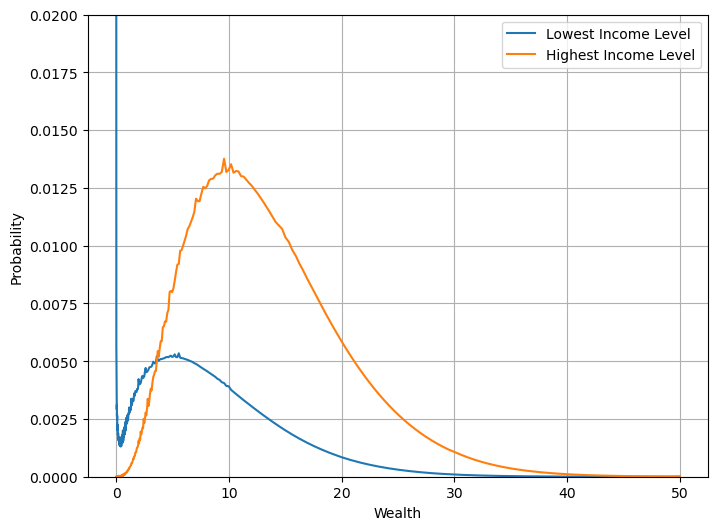

In [93]:
# Extract the distributions for the lowest and highest income levels
lowest_income_dist = stationary_dist[0, :]/np.sum(stationary_dist[0, :])
highest_income_dist = stationary_dist[-1, :]/np.sum(stationary_dist[-1, :])

# Plot the conditional marginal distributions of wealth
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(a_grid, lowest_income_dist, label="Lowest Income Level")
ax.plot(a_grid, highest_income_dist, label="Highest Income Level")
ax.set_xlabel("Wealth")
ax.set_ylabel("Probability")
ax.set_ylim(0, 0.02)
# ax.set_title("Marginal Wealth Distribution Conditional on Income Levels")
ax.legend()
ax.grid(True)
plt.show()

#### Plot Policy Functions

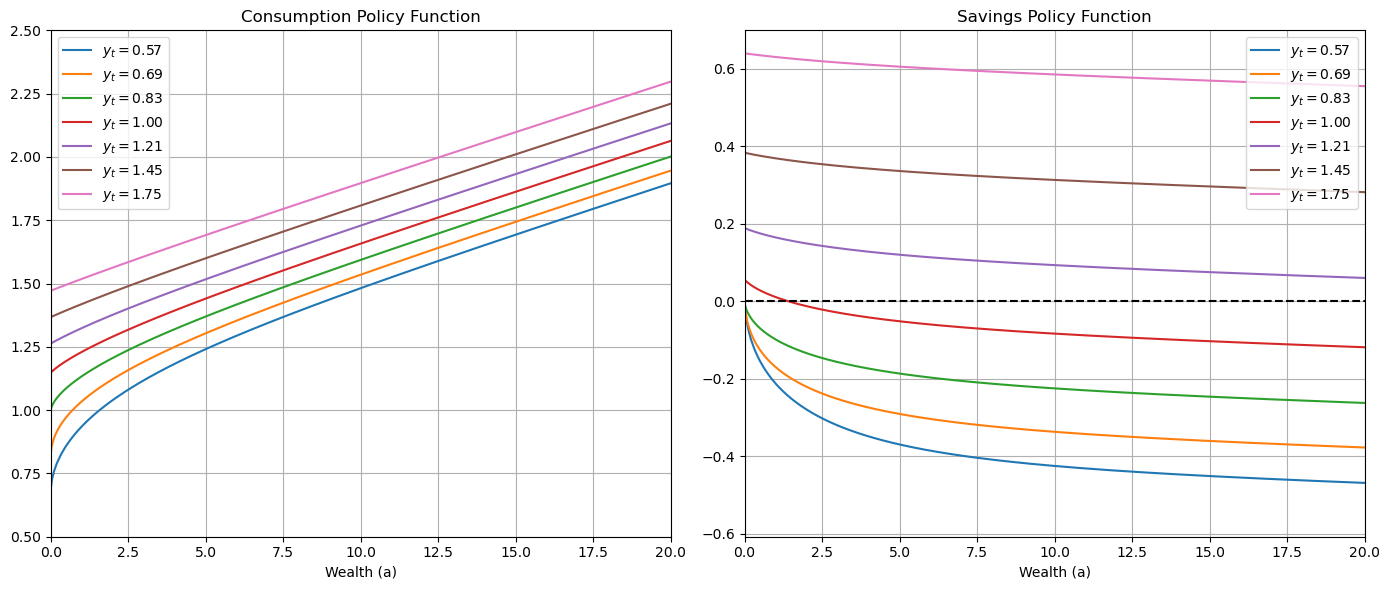

In [84]:
# Plot policy functions 

# Transpose consumption and savings
c_policy_egm = pol_functions['c'].T
sav_policy_egm = pol_functions['sav'].T
# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Consumption subplot
for z_idx in range(len(z_grid)):
    y_value = np.exp(z_grid[z_idx])  # Calculate y_t value
    ax1.plot(a_grid, c_policy_egm[:, z_idx], label=f'$y_t = {y_value:.2f}$')  # Use LaTeX formatting
ax1.set_xlabel('Wealth (a)')
# ax1.set_ylabel('Consumption (c)')
ax1.set_title('Consumption Policy Function')
ax1.set_xlim(0, 20)
ax1.set_ylim(0.5, 2.5)
ax1.legend()
ax1.grid(True)

# Savings subplot
for z_idx in range(len(z_grid)):
    y_value = np.exp(z_grid[z_idx])  # Calculate y_t value
    ax2.plot(a_grid, sav_policy_egm[:, z_idx], label=f'$y_t = {y_value:.2f}$')  # Use LaTeX formatting
ax2.set_xlabel('Wealth (a)')
# ax2.set_ylabel('Savings (s)')
ax2.set_title('Savings Policy Function')
ax2.set_xlim(0, 20)
ax2.legend()
ax2.axhline(0, color='black', linestyle='--')  # Add horizontal line at y=0
ax2.grid(True)

plt.tight_layout()
plt.show()

In [92]:
print(out)

{'Y': 1.9314193210460262, 'K': 5.9403680337864335, 'L': 1.0266257009555515, 'C': 1.4561898783433562, 'I': 0.47522944270267, 'w': 1.2040496982689952, 'r': 0.03704846427370303}
